# 🌲 04 — Random Forest Regressor
## Forêt aléatoire avec importance des features

Ce notebook utilise les features préparées par `00_Preprocessing` pour entraîner un Random Forest.

## 1. 📦 Imports & Chargement

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

print("✅ Imports OK")

✅ Imports OK


In [2]:
# Charger les données préparées
train = pd.read_csv("train_data.csv", index_col=0, parse_dates=True)
test = pd.read_csv("test_data.csv", index_col=0, parse_dates=True)

FEATURES = [c for c in train.columns if c != "revenue"]
TARGET = "revenue"

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"✅ Données chargées")
print(f"   X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"   X_test : {X_test.shape}, y_test : {y_test.shape}")
print(f"   Features: {len(FEATURES)}")

✅ Données chargées
   X_train: (36, 26), y_train: (36,)
   X_test : (12, 26), y_test : (12,)
   Features: 26


## 2. 🌲 Random Forest Manuel

In [3]:
# ── Random Forest optimisé (inspiré de XGBoost) ────────
# XGBoost réussi grâce à :
#   - régularisation (max_depth modéré, subsample)
#   - appris lentement (learning_rate) → pas applicable RF
#   - features importantes uniquement
#
# Adaptation RF :
#   - n_estimators=500 (compense l'absence de learning_rate)
#   - max_depth=5 (profondeur modérée = régularisation)
#   - min_samples_leaf=5 (feuilles plus grandes = moins de surapprentissage)
#   - max_features='sqrt' (comme subsample XGBoost → diversité)
#   - min_impurity_decrease=1e-5 (évite les splits inutiles)

print("🌲 Random Forest optimisé (inspiré XGBoost)")
print("   n_estimators=500, max_depth=5, min_samples_leaf=5")
print("   max_features='sqrt', min_impurity_decrease=1e-5")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=5,
    min_samples_split=8,
    max_features='sqrt',
    min_impurity_decrease=0.1,
    random_state=42,
    n_jobs=-2
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = np.mean(np.abs((y_test.values - rf_pred) / y_test.values)) * 100
rf_r2 = r2_score(y_test, rf_pred)

print(f"\n📊 Random Forest")
print(f"   MAE  : {rf_mae:>12,.0f} €")
print(f"   RMSE : {rf_rmse:>12,.0f} €")
print(f"   MAPE : {rf_mape:>11.2f} %")
print(f"   R²   : {rf_r2:>11.4f}")

🌲 Random Forest optimisé (inspiré XGBoost)
   n_estimators=500, max_depth=5, min_samples_leaf=5
   max_features='sqrt', min_impurity_decrease=1e-5

📊 Random Forest
   MAE  :   11,254,923 €
   RMSE :   14,242,983 €
   MAPE :       11.54 %
   R²   :      0.0914


## 3. 📊 Feature Importance & Sauvegarde

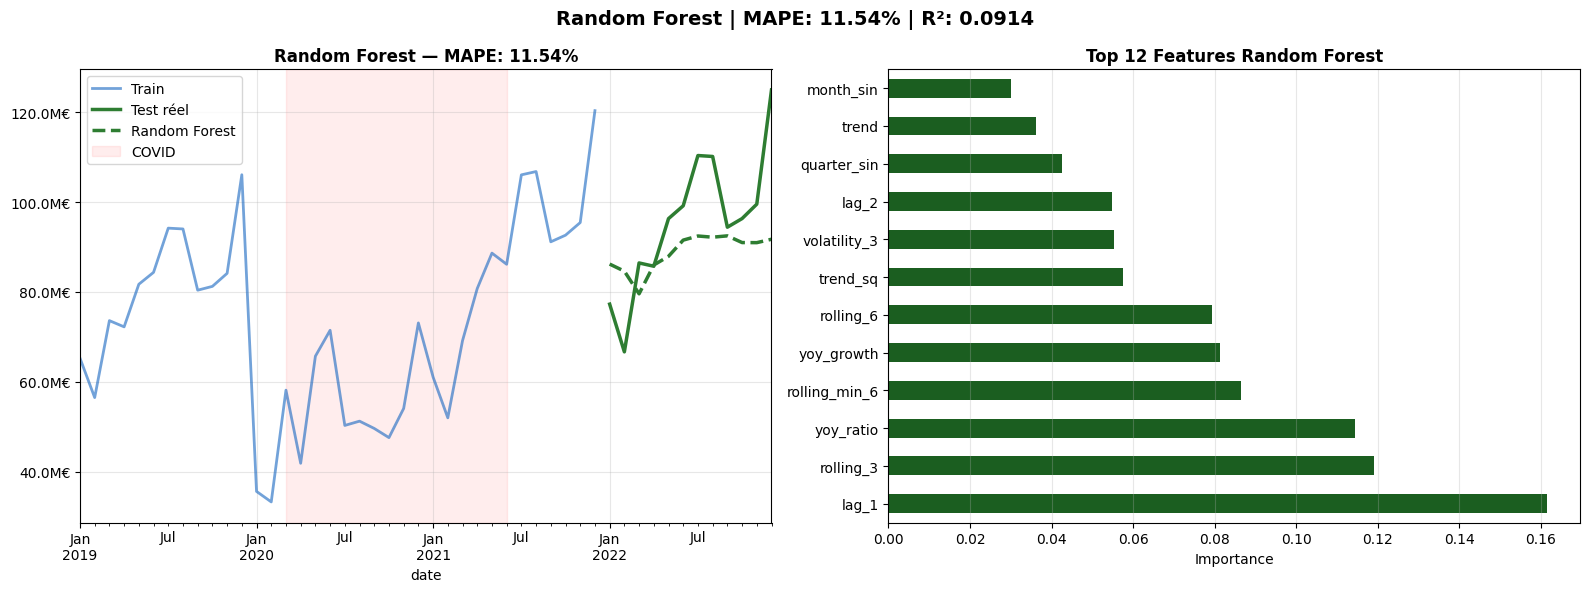

💾 Graphique → modele4_random_forest.png

📌 Top 5 features Random Forest :
                  lag_1 : 0.162
              rolling_3 : 0.119
              yoy_ratio : 0.114
          rolling_min_6 : 0.086
             yoy_growth : 0.081
💾 Prédictions → predictions_random_forest.csv


In [4]:
# Importance des features
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
y_train.plot(ax=ax, label="Train", color="#1565C0", alpha=0.6, linewidth=2)
y_test.plot(ax=ax, label="Test réel", color="#2E7D32", linewidth=2.5)
pd.Series(rf_pred, index=y_test.index).plot(ax=ax, label="Random Forest", color="#2E7D32", linestyle="--", linewidth=2.5)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"), alpha=0.07, color="red", label="COVID")
ax.set_title(f"Random Forest — MAPE: {rf_mape:.2f}%", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
top_features = importances.head(12)
colors_feat = ["#1B5E20" if v > 0.03 else "#90A4AE" for v in top_features.values]
top_features.plot(kind="barh", ax=ax2, color=colors_feat)
ax2.set_title("Top 12 Features Random Forest", fontsize=12, fontweight="bold")
ax2.set_xlabel("Importance"); ax2.grid(alpha=0.3, axis="x")

plt.suptitle(f"Random Forest | MAPE: {rf_mape:.2f}% | R²: {rf_r2:.4f}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("modele4_random_forest.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Graphique → modele4_random_forest.png")

print(f"\n📌 Top 5 features Random Forest :")
for feat, imp in importances.head(5).items():
    print(f"   {feat:>20} : {imp:.3f}")

# ── Sauvegarder ──────────────────────────────────────────
results_df = pd.DataFrame({"date": y_test.index, "reel": y_test, "prediction": rf_pred})
results_df.to_csv("predictions_random_forest.csv", index=False)
print("💾 Prédictions → predictions_random_forest.csv")